# EEG-Bench Results Analysis

This notebook analyzes benchmark results from EEG-Bench experiments.

**Features:**
- Load all experiment results from JSON files
- Data efficiency curves (accuracy vs. training data %)
- Model comparison tables and heatmaps
- BCI vs Clinical task analysis

## 1. Setup & Data Loading

In [114]:
import json
import glob
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, cohen_kappa_score
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Task categorization
BCI_TASKS = ['Five Fingers MI', 'Left Hand vs Right Hand vs Feet vs Tongue MI',]
CLINICAL_TASKS = [
    "parkinsons", "schizophrenia", "mtbi", "ocd", "epilepsy",
    "abnormal", "sleep_stages", "seizure", "binary_artifact", "multiclass_artifact"
]

# Friendly names for display
TASK_DISPLAY_NAMES = {
    "left_right": "Left/Right Hand",
    "right_feet": "Right Hand/Feet",
    "left_right_feet_tongue": "4-Class MI",
    "5_fingers": "5 Fingers",
    "parkinsons": "Parkinson's",
    "schizophrenia": "Schizophrenia",
    "mtbi": "mTBI",
    "ocd": "OCD",
    "epilepsy": "Epilepsy",
    "abnormal": "Abnormal EEG",
    "sleep_stages": "Sleep Stages",
    "seizure": "Seizure",
    "binary_artifact": "Artifact (Binary)",
    "multiclass_artifact": "Artifact (Multi)"
}

MODEL_DISPLAY_NAMES = {
    "LaBraMModel": "LaBraM",
    "BENDRModel": "BENDR",
    "NeuroGPTModel": "NeuroGPT",
    "REVEBenchmarkModel": "REVE",
    "REVEClinicalModel": "REVE",
    "LeJEPABCI": "LeJEPA",
    "LeJEPAClinical": "LeJEPA",
    "CSPLDAModel": "CSP-LDA",
    "CSPSVMModel": "CSP-SVM",
    "BrainfeaturesLDAModel": "LDA",
    "BrainfeaturesSVMModel": "SVM"
}

In [115]:

from collections.abc import Sequence


def _flatten_label_structure(values):
    """Recursively flatten nested predictions/labels regardless of depth."""
    if values is None:
        return []
    if isinstance(values, np.ndarray):
        return values.reshape(-1).tolist()
    if isinstance(values, Sequence) and not isinstance(values, (str, bytes)):
        flattened = []
        for item in values:
            flattened.extend(_flatten_label_structure(item))
        return flattened
    return [values]


def compute_metrics(y_true, y_pred):
    """Compute classification metrics from predictions (robust to nesting)."""
    y_true_flat = _flatten_label_structure(y_true)
    y_pred_flat = _flatten_label_structure(y_pred)

    if not y_true_flat or not y_pred_flat:
        return {
            "accuracy": np.nan,
            "balanced_accuracy": np.nan,
            "f1_weighted": np.nan,
            "f1_macro": np.nan,
            "kappa": np.nan,
        }

    min_len = min(len(y_true_flat), len(y_pred_flat))
    y_true_arr = np.asarray(y_true_flat[:min_len])
    y_pred_arr = np.asarray(y_pred_flat[:min_len])

    metrics = {
        "accuracy": accuracy_score(y_true_arr, y_pred_arr),
        "balanced_accuracy": balanced_accuracy_score(y_true_arr, y_pred_arr),
        "f1_weighted": f1_score(y_true_arr, y_pred_arr, average="weighted", zero_division=0),
        "f1_macro": f1_score(y_true_arr, y_pred_arr, average="macro", zero_division=0),
        "kappa": cohen_kappa_score(y_true_arr, y_pred_arr),
    }
    return metrics


def _parse_eval_noise(data: dict) -> dict:
    """Parse evaluation noise metadata with backward compatibility."""
    eval_noise = data.get("eval_noise") or {}
    tag = eval_noise.get("tag", "clean")
    snr_db = eval_noise.get("snr_db")
    noise_types = eval_noise.get("noise_types") or []
    is_clean = snr_db is None
    return {
        "noise_tag": tag,
        "noise_snr_db": snr_db,
        "noise_types": noise_types,
        "is_clean": is_clean,
    }


def load_results(results_dir="results/raw"):
    """Load all results JSON files into a DataFrame."""
    records = []

    json_files = glob.glob(os.path.join(results_dir, "*.json"))
    print(f"Found {len(json_files)} result files")

    for filepath in json_files:
        try:
            with open(filepath) as f:
                data = json.load(f)

            task_name = data.get("task_name", "unknown")
            model_names = data.get("models_names", ["unknown"])
            percentage = data.get("data_percentage", 1.0)
            linear_probe = data.get("linear_probe", False)
            timestamp = data.get("timestamp", "")
            data_stats = data.get("data_stats", {})
            ckpt_id = data.get("checkpoint_id", {})
            step = 'None'
            result_prefix = data.get("result_prefix", "").replace('lejepa', '')
            if ckpt_id:
                step = int(ckpt_id.split('step_')[-1]) if 'last' not in ckpt_id else ckpt_id

            noise_info = _parse_eval_noise(data)

            y_test = data.get("y_test", [[]])
            results = data.get("results", [[]])

            # Process each model's results
            for i, model_name in enumerate(model_names):
                try:
                    # Get predictions for this model (handle nested structure)
                    if i < len(results):
                        y_pred = results[i] if isinstance(results[i], list) else results
                        y_true = y_test[i] if i < len(y_test) and isinstance(y_test[i], list) else y_test
                    else:
                        y_pred = results[0] if results else []
                        y_true = y_test[0] if y_test else []

                    # Compute metrics
                    metrics = compute_metrics(y_true, y_pred)

                    # Clean up model name for display
                    display_name = MODEL_DISPLAY_NAMES.get(model_name, model_name)

                    record = {
                        "task": task_name,
                        "task_display": TASK_DISPLAY_NAMES.get(task_name, task_name),
                        "task_type": "BCI" if task_name in BCI_TASKS else "Clinical",
                        "model": model_name + result_prefix,
                        "model_display": display_name + result_prefix,
                        "percentage": percentage,
                        "linear_probe": linear_probe,
                        "timestamp": timestamp,
                        # "total_samples": data_stats.get("total_samples", 0),
                        "file": os.path.basename(filepath),
                        "step": step,
                        **noise_info,
                        **metrics,
                    }
                    records.append(record)

                except Exception:
                    raise

        except Exception:
            raise

    df = pd.DataFrame(records)
    print(f"Loaded {len(df)} experiment results")
    return df


In [116]:

# Load results (clean + noise-aware)
df_all = load_results("results/raw")
# df_labram = load_results('results/labr')
df_labram = pd.read_csv('results/labram_results_all.csv')
df_labram['noise_types'] = df_labram['noise_types'].apply(lambda x: eval(x))

df_all = pd.concat([df_all, df_labram])

df_clean = df_all.copy()
df_noise = df_all.iloc[0:0].copy()

if len(df_all) > 0:
    # Normalize noise types for grouping/labels
    if "noise_types" in df_all.columns:
        df_all["noise_types_str"] = df_all["noise_types"].apply(
            lambda x: "+".join(x) if isinstance(x, (list, tuple)) else ""
        )
    else:
        df_all["noise_types_str"] = ""

    df_clean = df_all[df_all["is_clean"]].copy() if "is_clean" in df_all.columns else df_all.copy()
    df_noise = df_all[~df_all["is_clean"]].copy() if "is_clean" in df_all.columns else df_all.iloc[0:0].copy()

    # IMPORTANT: all existing plots below should use clean-only results
    df = df_clean

    print(f"Clean results: {len(df_clean)} rows")
    print(f"Noise results: {len(df_noise)} rows")
    print(f"Unique tasks (clean): {df['task'].nunique()}")
    print(f"Unique models (clean): {df['model_display'].nunique()}")
    print(f"Data percentages (clean): {sorted(df['percentage'].unique())}")
    print(f"Tasks (clean): {df['task'].unique().tolist()}")
    print(f"Models (clean): {df['model_display'].unique().tolist()}")
    print(f"Steps (clean): {df['step'].unique().tolist()}")
else:
    print("No results found. Run experiments first with run_experiments.py")


Found 130 result files
Loaded 130 experiment results
Clean results: 136 rows
Noise results: 71 rows
Unique tasks (clean): 14
Unique models (clean): 7
Data percentages (clean): [0.25, 0.5, 0.75, 1.0]
Tasks (clean): ['abnormal_clinical', 'binary_artifact_clinical', 'schizophrenia_clinical', 'mtbi_clinical', 'Five Fingers MI', 'ocd_clinical', 'Right Hand vs Feet MI', 'seizure_clinical', 'sleep_stages_clinical', 'multiclass_artifact_clinical', 'Left Hand vs Right Hand vs Feet vs Tongue MI', 'epilepsy_clinical', 'parkinsons_clinical', 'Left Hand vs Right Hand MI']
Models (clean): ['LeJEPA_base_global_proj', 'LeJEPA_base_global_projv2_smallds', 'LeJEPA_vitb_global_proj_v2', 'LeJEPA_vitb_global_proj', 'LeJEPA_base_global_projv2', 'LeJEPA_base_global_proj_channelmixerv1_short', 'LaBraM']
Steps (clean): ['last', nan]


In [117]:
# Drop duplicates (exclude unhashable list columns like noise_types)
unhashable_cols = {"noise_types"}
exclude_cols = {"timestamp", "file"} | unhashable_cols

subset_cols = [c for c in df.columns if c not in exclude_cols]
df = df_clean.drop_duplicates(subset=subset_cols)

print(f"After deduplication: {len(df)} rows")


After deduplication: 136 rows


In [118]:
df

,task,task_display,task_type,model,model_display,percentage,linear_probe,timestamp,file,step,noise_tag,noise_snr_db,noise_types,is_clean,accuracy,balanced_accuracy,f1_weighted,f1_macro,kappa,noise_types_str
2,abnormal_clinical,abnormal_clinical,Clinical,LeJEPAClinical_base_global_proj,LeJEPA_base_global_proj,1.00,True,20260126_145807,lejepa_base_global_proj_abnormal_clinical_LeJE...,last,clean,NaN,[],True,0.797101,0.793016,0.796410,0.794337,0.589024,
5,binary_artifact_clinical,binary_artifact_clinical,Clinical,LeJEPAClinical_base_global_projv2_smallds,LeJEPA_base_global_projv2_smallds,1.00,True,20260126_174803,lejepa_base_global_projv2_smallds_binary_artif...,last,clean,NaN,[],True,0.692924,0.689631,0.696582,0.682287,0.367167,
6,schizophrenia_clinical,schizophrenia_clinical,Clinical,LeJEPAClinical_vitb_global_proj_v2,LeJEPA_vitb_global_proj_v2,1.00,True,20260127_152824,lejepa_vitb_global_proj_v2_schizophrenia_clini...,last,clean,NaN,[],True,0.384615,0.404762,0.338462,0.350000,-0.181818,
7,mtbi_clinical,mtbi_clinical,Clinical,LeJEPAClinical_vitb_global_proj,LeJEPA_vitb_global_proj,1.00,True,20260126_190406,lejepa_vitb_global_proj_mtbi_clinical_LeJEPACl...,last,clean,NaN,[],True,0.678571,0.500000,0.548632,0.404255,0.000000,
8,Five Fingers MI,Five Fingers MI,BCI,LeJEPABCI_base_global_proj,LeJEPA_base_global_proj,1.00,True,20260126_143526,lejepa_base_global_proj_Five Fingers MI_LeJEPA...,last,clean,NaN,[],True,0.183254,0.183070,0.178065,0.177366,-0.020808,
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,binary_artifact_clinical,binary_artifact_clinical,Clinical,LaBraMModel,LaBraM,1.00,True,20260127_071100,binary_artifact_clinical_LaBraMModel_LP_202601...,NaN,clean,NaN,[],True,0.688475,0.696736,0.693206,0.682451,0.372387,
73,epilepsy_clinical,epilepsy_clinical,Clinical,LaBraMModel,LaBraM,0.50,True,20260127_124711,epilepsy_clinical_LaBraMModel_pct50_LP_2026012...,NaN,clean,NaN,[],True,0.658098,0.610717,0.660595,0.608874,0.218037,
74,schizophrenia_clinical,schizophrenia_clinical,Clinical,LaBraMModel,LaBraM,0.75,True,20260127_081741,schizophrenia_clinical_LaBraMModel_pct75_LP_20...,NaN,clean,NaN,[],True,0.538462,0.500000,0.376923,0.350000,0.000000,
75,parkinsons_clinical,parkinsons_clinical,Clinical,LaBraMModel,LaBraM,0.25,True,20260127_153804,parkinsons_clinical_LaBraMModel_pct25_LP_20260...,NaN,clean,NaN,[],True,0.516340,0.454917,0.503896,0.450388,-0.093913,


In [119]:
#add baseline results (WILL NEED TO KEEP UPDATING THIS AS IT COMES!)
baseline_df = None
# baseline_df = pd.read_csv('/home/spanchavati/EEG-Bench-vICMl/results/baseline_results.csv', index_col=0)

if baseline_df is not None:
    # baseline_df = baseline_df[baseline_df['model_display'].str.lower().str.contains('labram')]
    df = pd.concat([df, baseline_df], ignore_index=True)
    print(f"\nAfter adding baseline results:")
    print(f"Unique tasks: {df['task'].nunique()}")
    print(f"Unique models: {df['model_display'].nunique()}")


In [120]:
# Preview data
if len(df) > 0:
    display(df.head(10))

,task,task_display,task_type,model,model_display,percentage,linear_probe,timestamp,file,step,noise_tag,noise_snr_db,noise_types,is_clean,accuracy,balanced_accuracy,f1_weighted,f1_macro,kappa,noise_types_str
2,abnormal_clinical,abnormal_clinical,Clinical,LeJEPAClinical_base_global_proj,LeJEPA_base_global_proj,1.0,True,20260126_145807,lejepa_base_global_proj_abnormal_clinical_LeJE...,last,clean,NaN,[],True,0.797101,0.793016,0.796410,0.794337,0.589024,
5,binary_artifact_clinical,binary_artifact_clinical,Clinical,LeJEPAClinical_base_global_projv2_smallds,LeJEPA_base_global_projv2_smallds,1.0,True,20260126_174803,lejepa_base_global_projv2_smallds_binary_artif...,last,clean,NaN,[],True,0.692924,0.689631,0.696582,0.682287,0.367167,
6,schizophrenia_clinical,schizophrenia_clinical,Clinical,LeJEPAClinical_vitb_global_proj_v2,LeJEPA_vitb_global_proj_v2,1.0,True,20260127_152824,lejepa_vitb_global_proj_v2_schizophrenia_clini...,last,clean,NaN,[],True,0.384615,0.404762,0.338462,0.350000,-0.181818,
7,mtbi_clinical,mtbi_clinical,Clinical,LeJEPAClinical_vitb_global_proj,LeJEPA_vitb_global_proj,1.0,True,20260126_190406,lejepa_vitb_global_proj_mtbi_clinical_LeJEPACl...,last,clean,NaN,[],True,0.678571,0.500000,0.548632,0.404255,0.000000,
8,Five Fingers MI,Five Fingers MI,BCI,LeJEPABCI_base_global_proj,LeJEPA_base_global_proj,1.0,True,20260126_143526,lejepa_base_global_proj_Five Fingers MI_LeJEPA...,last,clean,NaN,[],True,0.183254,0.183070,0.178065,0.177366,-0.020808,
9,ocd_clinical,ocd_clinical,Clinical,LeJEPAClinical_base_global_projv2,LeJEPA_base_global_projv2,1.0,True,20260127_152906,lejepa_base_global_projv2_ocd_clinical_LeJEPAC...,last,clean,NaN,[],True,0.909091,0.900000,0.907537,0.905983,0.813559,
10,abnormal_clinical,abnormal_clinical,Clinical,LeJEPAClinical_base_global_proj_channelmixerv1...,LeJEPA_base_global_proj_channelmixerv1_short,1.0,True,20260126_134405,lejepa_base_global_proj_channelmixerv1_short_a...,last,clean,NaN,[],True,0.797101,0.791111,0.795657,0.793181,0.587444,
11,Right Hand vs Feet MI,Right Hand vs Feet MI,Clinical,LeJEPABCI_base_global_proj,LeJEPA_base_global_proj,1.0,True,20260126_154601,lejepa_base_global_proj_Right Hand vs Feet MI_...,last,clean,NaN,[],True,0.577314,0.579940,0.578946,0.576160,0.156919,
13,seizure_clinical,seizure_clinical,Clinical,LeJEPAClinical_vitb_global_proj,LeJEPA_vitb_global_proj,1.0,True,20260126_201000,lejepa_vitb_global_proj_seizure_clinical_LeJEP...,last,clean,NaN,[],True,0.806580,0.661796,0.890024,0.454522,0.010250,
14,Five Fingers MI,Five Fingers MI,BCI,LeJEPABCI_vitb_global_proj_v2,LeJEPA_vitb_global_proj_v2,1.0,True,20260126_221821,lejepa_vitb_global_proj_v2_Five Fingers MI_LeJ...,last,clean,NaN,[],True,0.203791,0.203001,0.202558,0.201868,0.003593,


## 2. Data Efficiency Curves

Plots showing how model performance changes with varying amounts of training data.

In [121]:
def plot_data_efficiency(df, task, metric="balanced_accuracy", figsize=(10, 6)):
    """Plot data efficiency curve for a single task."""
    task_df = df[df["task"] == task].copy()
    
    if len(task_df) == 0:
        print(f"No data for task: {task}")
        return
    
    plt.figure(figsize=figsize)
    
    models = task_df["model_display"].unique()
    colors = plt.cm.tab10(np.linspace(0, 1, len(models)))
    
    for model, color in zip(models, colors):
        model_df = task_df[task_df["model_display"] == model].sort_values("percentage")
        
        # Group by percentage and compute mean/std if multiple runs
        grouped = model_df.groupby("percentage")[metric].agg(["mean", "std"]).reset_index()
        
        plt.plot(grouped["percentage"] * 100, grouped["mean"],
                 marker='o', label=model, color=color, linewidth=2, markersize=8)
        
        # Add error bars if std available
        if grouped["std"].notna().any():
            plt.fill_between(grouped["percentage"] * 100,
                           grouped["mean"] - grouped["std"],
                           grouped["mean"] + grouped["std"],
                           alpha=0.2, color=color)
    
    task_display = TASK_DISPLAY_NAMES.get(task, task)
    plt.xlabel("Training Data (%)", fontsize=12)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=12)
    plt.title(f"Data Efficiency: {task_display}", fontsize=14)
    plt.legend(loc="lower right", fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xlim(0, 105)
    plt.ylim(0, 1.05)
    plt.tight_layout()
    plt.show()


def plot_all_efficiency_curves(df, metric="balanced_accuracy", tasks=None):
    """Plot data efficiency curves for all tasks."""
    if tasks is None:
        tasks = df["task"].unique()
    
    for task in tasks:
        plot_data_efficiency(df, task, metric)

In [122]:
# # Plot efficiency curves for all tasks
# if len(df) > 0:
#     plot_all_efficiency_curves(df, metric="accuracy")

In [123]:
def plot_efficiency_grid(df, metric="balanced_accuracy", ncols=3):
    """Plot all efficiency curves in a grid layout."""
    tasks = df["task"].unique()
    nrows = int(np.ceil(len(tasks) / ncols))
    
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten() if len(tasks) > 1 else [axes]
    
    models = df["model_display"].unique()
    colors = {m: plt.cm.tab10(i/len(models)) for i, m in enumerate(models)}
    
    for idx, task in enumerate(tasks):
        ax = axes[idx]
        task_df = df[df["task"] == task]
        
        for model in models:
            model_df = task_df[task_df["model_display"] == model].sort_values("percentage")
            if len(model_df) > 0:
                grouped = model_df.groupby("percentage")[metric].mean().reset_index()
                ax.plot(grouped["percentage"] * 100, grouped[metric],
                       marker='o', label=model, color=colors[model], linewidth=2)
        
        ax.set_title(TASK_DISPLAY_NAMES.get(task, task), fontsize=11)
        ax.set_xlabel("Training Data (%)")
        ax.set_ylabel(metric.replace("_", " ").title())
        ax.set_xlim(0, 105)
        ax.set_ylim(0, 1.05)
        ax.grid(True, alpha=0.3)
    
    # Hide empty subplots
    for idx in range(len(tasks), len(axes)):
        axes[idx].set_visible(False)
    
    # Add legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=min(5, len(models)),
              bbox_to_anchor=(0.5, 1.02), fontsize=10)
    
    plt.tight_layout()
    plt.subplots_adjust(top=0.92)
    plt.savefig("results/efficiency_curves_grid.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to results/efficiency_curves_grid.png")

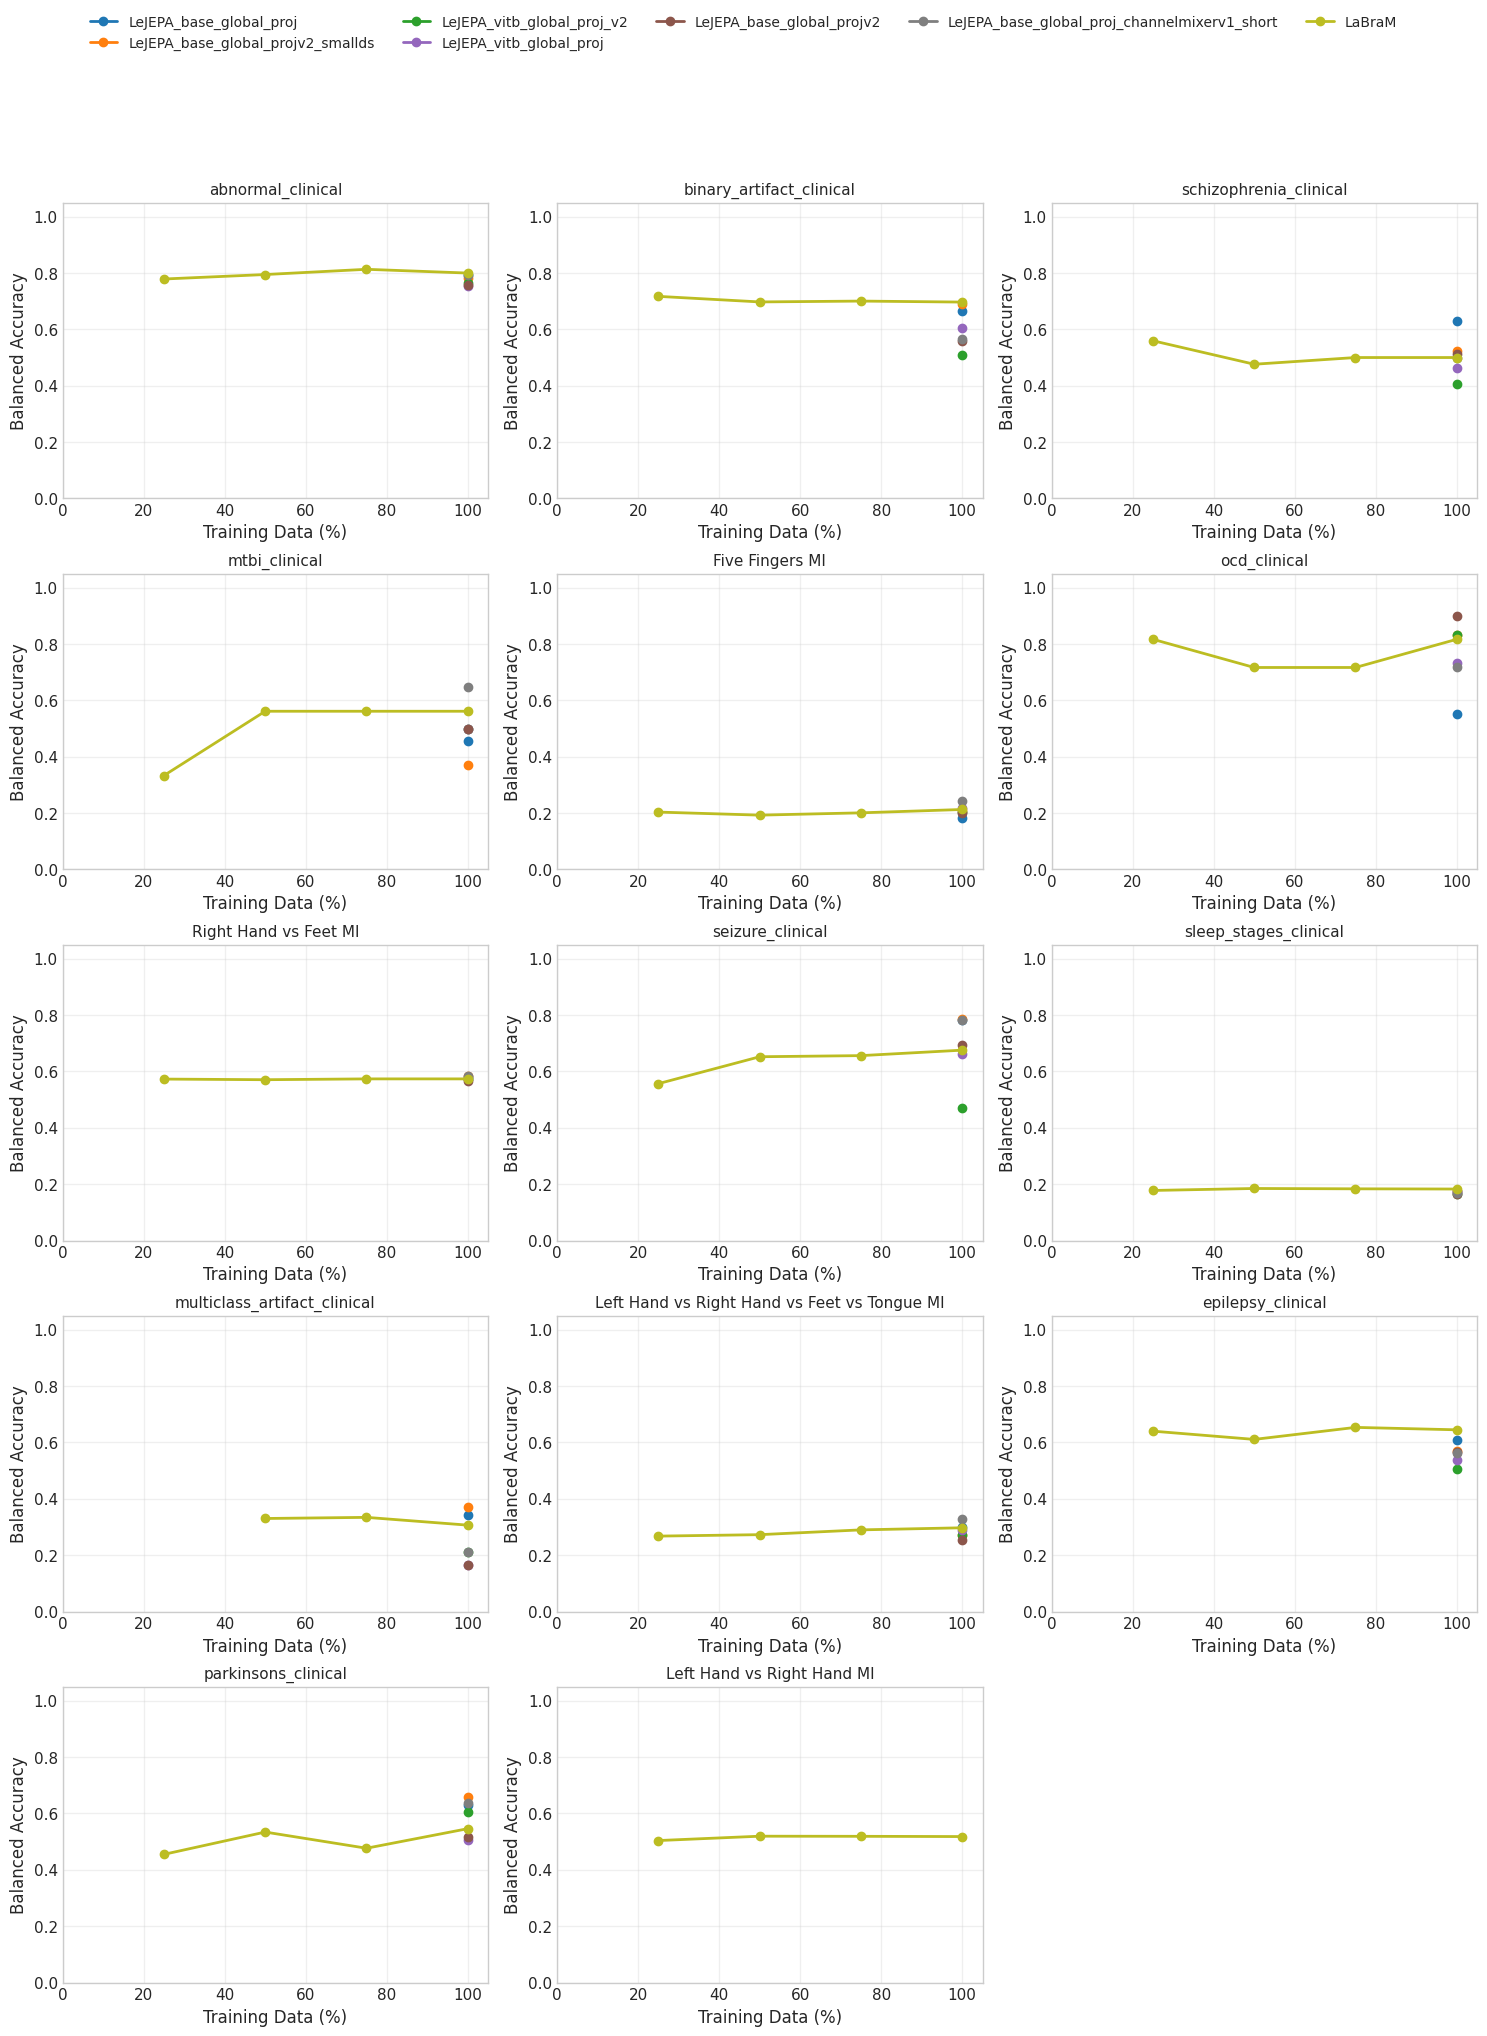

Saved to results/efficiency_curves_grid.png


In [124]:
# Plot grid view
if len(df) > 0 and df["task"].nunique() > 1:
    plot_efficiency_grid(df)

## 3. Model Comparison Tables

In [125]:
def model_comparison_table(df, percentage=1.0, metric="balanced_accuracy"):
    """Create pivot table: models (rows) x tasks (columns)."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        print(f"No data for percentage={percentage}")
        return None
    
    table = subset.pivot_table(
        values=metric,
        index="model_display",
        columns="task_display",
        aggfunc="mean"
    )
    
    # Add mean column
    table["Mean"] = table.mean(axis=1)
    
    # Sort by mean performance
    table = table.sort_values("Mean", ascending=False)
    
    return table.round(3)

In [126]:
# Display comparison table at 100% data
if len(df) > 0:
    table = model_comparison_table(df, percentage=1.0)
    if table is not None:
        print("Model Comparison (100% training data, Balanced Accuracy):")
        display(table.style.background_gradient(cmap="RdYlGn", axis=None))

Model Comparison (100% training data, Balanced Accuracy):


task_display,Five Fingers MI,Left Hand vs Right Hand MI,Left Hand vs Right Hand vs Feet vs Tongue MI,Right Hand vs Feet MI,abnormal_clinical,binary_artifact_clinical,epilepsy_clinical,mtbi_clinical,multiclass_artifact_clinical,ocd_clinical,parkinsons_clinical,schizophrenia_clinical,seizure_clinical,sleep_stages_clinical,Mean
model_display,,,,,,,,,,,,,,,
LeJEPA_base_global_projv2_smallds,0.207000,nan,0.270000,0.585000,0.784000,0.690000,0.570000,0.371000,0.372000,0.833000,0.658000,0.524000,0.784000,0.175000,0.525000
LaBraM,0.213000,0.518000,0.297000,0.573000,0.800000,0.697000,0.645000,0.561000,0.307000,0.817000,0.546000,0.500000,0.675000,0.183000,0.524000
LeJEPA_base_global_proj_channelmixerv1_short,0.242000,nan,0.327000,0.584000,0.791000,0.567000,0.562000,0.646000,0.211000,0.717000,0.637000,0.500000,0.782000,0.169000,0.518000
LeJEPA_base_global_proj,0.183000,nan,0.301000,0.580000,0.793000,0.665000,0.608000,0.456000,0.342000,0.550000,0.632000,0.631000,0.782000,0.174000,0.515000
LeJEPA_base_global_projv2,0.201000,nan,0.253000,0.568000,0.758000,0.560000,0.567000,0.500000,0.166000,0.900000,0.516000,0.512000,0.693000,0.166000,0.489000
LeJEPA_vitb_global_proj,0.219000,nan,0.289000,0.572000,0.754000,0.605000,0.538000,0.500000,0.164000,0.733000,0.505000,0.464000,0.662000,0.174000,0.475000
LeJEPA_vitb_global_proj_v2,0.203000,nan,0.271000,0.574000,0.764000,0.511000,0.507000,0.500000,0.213000,0.833000,0.605000,0.405000,0.469000,0.165000,0.463000


In [127]:
def plot_comparison_heatmap(df, percentage=1.0, metric="balanced_accuracy", figsize=(14, 6)):
    """Plot heatmap of model performance across tasks."""
    table = model_comparison_table(df, percentage, metric)
    
    if table is None or len(table) == 0:
        return
    
    # Remove Mean column for heatmap
    plot_table = table.drop(columns=["Mean"], errors="ignore")
    
    plt.figure(figsize=figsize)
    sns.heatmap(plot_table, annot=True, cmap="RdYlGn", fmt=".2f",
                vmin=0, vmax=1, linewidths=0.5,
                cbar_kws={"label": metric.replace("_", " ").title()})
    plt.title(f"Model {metric.replace('_', ' ').title()} by Task ({int(percentage*100)}% training data)",
              fontsize=14)
    plt.xlabel("Task", fontsize=12)
    plt.ylabel("Model", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(f"results/comparison_heatmap_{metric}.png", dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Saved to results/comparison_heatmap_{metric}.png")

/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/matrix.py:260: FutureWarning: Format strings passed to MaskedConstant are ignored, but in future may error or produce different behavior
  annotation = ("{:" + self.fmt + "}").format(val)


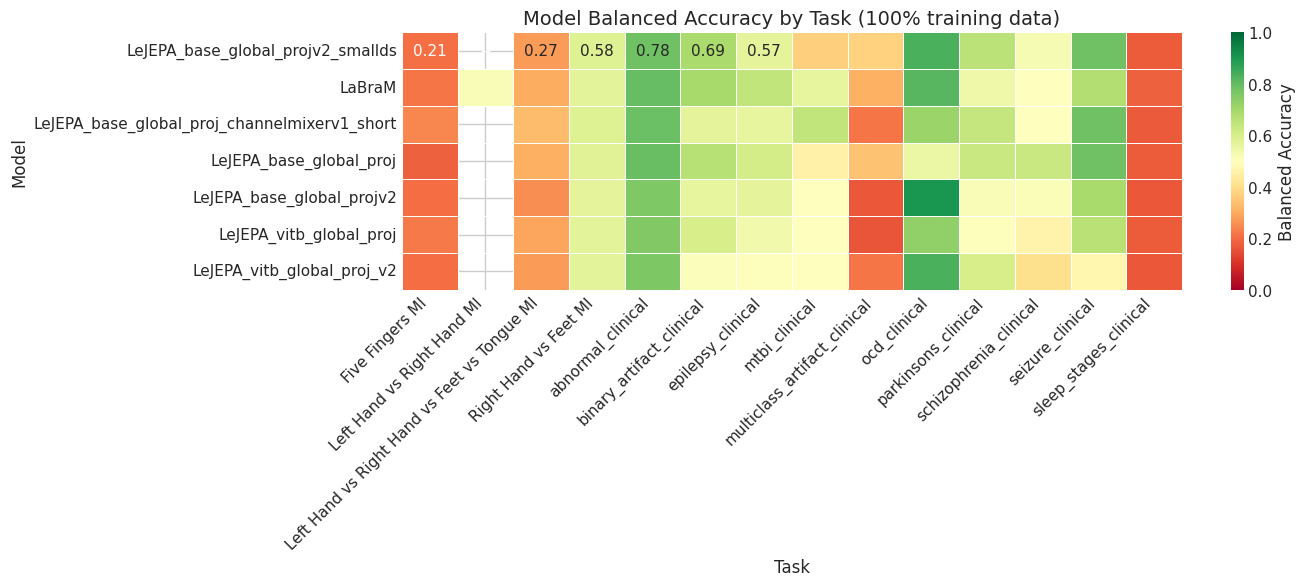

Saved to results/comparison_heatmap_balanced_accuracy.png


In [128]:
# Plot heatmap
if len(df) > 0:
    plot_comparison_heatmap(df, percentage=1.0, metric="balanced_accuracy")

## 4. Summary Statistics

In [183]:
def best_model_per_task(df, percentage=1.0, metric="balanced_accuracy"):
    """Find the best performing model for each task."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return None
    
    # Group and find best
    max_acc = subset.groupby('task')['balanced_accuracy'].transform('max')
    best = subset[subset['balanced_accuracy'] == max_acc][['task', 'task_display', 'model_display', 'balanced_accuracy']].copy()
    best = best.rename(columns={metric: f"best_{metric}"})
    best = best.sort_values("task_display")
    
    return best

In [184]:
# Best model per task
if len(df) > 0:
    best = best_model_per_task(df)
    if best is not None:
        print("Best Model per Task (100% training data)")
        display(best)

Best Model per Task (100% training data)


,task,task_display,model_display,best_balanced_accuracy
42,Five Fingers MI,Five Fingers MI,LeJEPA_base_global_proj_channelmixerv1_short,0.242012
23,Left Hand vs Right Hand MI,Left Hand vs Right Hand MI,LaBraM,0.518028
28,Left Hand vs Right Hand vs Feet vs Tongue MI,Left Hand vs Right Hand vs Feet vs Tongue MI,LeJEPA_base_global_proj_channelmixerv1_short,0.326615
29,Right Hand vs Feet MI,Right Hand vs Feet MI,LeJEPA_base_global_projv2_smallds,0.584868
52,abnormal_clinical,abnormal_clinical,LaBraM,0.799683
72,binary_artifact_clinical,binary_artifact_clinical,LaBraM,0.696736
57,epilepsy_clinical,epilepsy_clinical,LaBraM,0.644778
125,mtbi_clinical,mtbi_clinical,LeJEPA_base_global_proj_channelmixerv1_short,0.646199
27,multiclass_artifact_clinical,multiclass_artifact_clinical,LeJEPA_base_global_projv2_smallds,0.371685
9,ocd_clinical,ocd_clinical,LeJEPA_base_global_projv2,0.900000


In [185]:
#what model has the most bests? 
w = best['model_display'].value_counts()
w

model_display
LaBraM                                          5
LeJEPA_base_global_projv2_smallds               4
LeJEPA_base_global_proj_channelmixerv1_short    3
LeJEPA_base_global_projv2                       1
LeJEPA_base_global_proj                         1
Name: count, dtype: int64

In [186]:
# def compute_model_rankings(df, percentage=1.0, metric="balanced_accuracy"):
#     """Compute average rank of each model across tasks."""
#     subset = df[df["percentage"] == percentage].copy()
    
#     if len(subset) == 0:
#         return None
    
#     # Compute rank per task (1 = best)
#     subset["rank"] = subset.groupby("task")[metric].rank(ascending=False)
    
#     # Average rank per model
#     rankings = subset.groupby("model_display").agg({
#         "rank": "mean",
#         metric: "mean"
#     }).round(2)
    
#     rankings = rankings.sort_values("rank")
#     rankings.columns = ["Avg Rank", f"Avg {metric.title()}"]
    
#     return rankings

def compute_model_rankings(df, percentage=1.0, metric="balanced_accuracy"):
    """Compute average rank of each model across tasks (only tasks with 2+ models)."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return None
    
    # Only include tasks that have multiple models
    task_model_counts = subset.groupby("task")["model_display"].nunique()
    tasks_with_multiple_models = task_model_counts[task_model_counts > 1].index
    print(len(tasks_with_multiple_models))
    subset = subset[subset["task"].isin(tasks_with_multiple_models)]
    
    if len(subset) == 0:
        print("No tasks with multiple models to rank")
        return None
    
    # Compute rank per task (1 = best)
    subset["rank"] = subset.groupby("task")[metric].rank(ascending=False)
    
    # Average rank per model
    rankings = subset.groupby("model_display").agg({
        "rank": "mean",
        metric: "mean"
    }).round(2)
    
    rankings = rankings.sort_values("rank")
    rankings.columns = ["Avg Rank", f"Avg {metric.title()}"]
    
    return rankings

In [187]:
# Model rankings
if len(df) > 0:
    rankings = compute_model_rankings(df)
    if rankings is not None:
        print("Model Rankings (lower rank = better)")
        display(rankings)

13
Model Rankings (lower rank = better)


,Avg Rank,Avg Balanced_Accuracy
model_display,,
LaBraM,2.96,0.52
LeJEPA_base_global_projv2_smallds,2.96,0.54
LeJEPA_base_global_proj_channelmixerv1_short,3.27,0.52
LeJEPA_base_global_proj,3.38,0.52
LeJEPA_vitb_global_proj,5.31,0.48
LeJEPA_vitb_global_proj_v2,5.35,0.46
LeJEPA_base_global_projv2,5.36,0.47


## 5. BCI vs Clinical Comparison

In [188]:
def plot_bci_vs_clinical(df, percentage=1.0, metric="accuracy"):
    """Compare model performance on BCI vs Clinical tasks."""
    subset = df[df["percentage"] == percentage].copy()
    
    if len(subset) == 0:
        return
    
    # Group by model and task type
    comparison = subset.groupby(["model_display", "task_type"])[metric].mean().unstack()
    comparison = comparison.sort_values("BCI", ascending=False) if "BCI" in comparison.columns else comparison
    
    # Plot
    ax = comparison.plot(kind="bar", figsize=(12, 6), width=0.8)
    plt.xlabel("Model", fontsize=12)
    plt.ylabel(metric.replace("_", " ").title(), fontsize=12)
    plt.title(f"BCI vs Clinical Performance ({int(percentage*100)}% training data)", fontsize=14)
    plt.xticks(rotation=45, ha="right")
    plt.legend(title="Task Type", fontsize=10)
    plt.ylim(0, 1)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("results/bci_vs_clinical.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Saved to results/bci_vs_clinical.png")

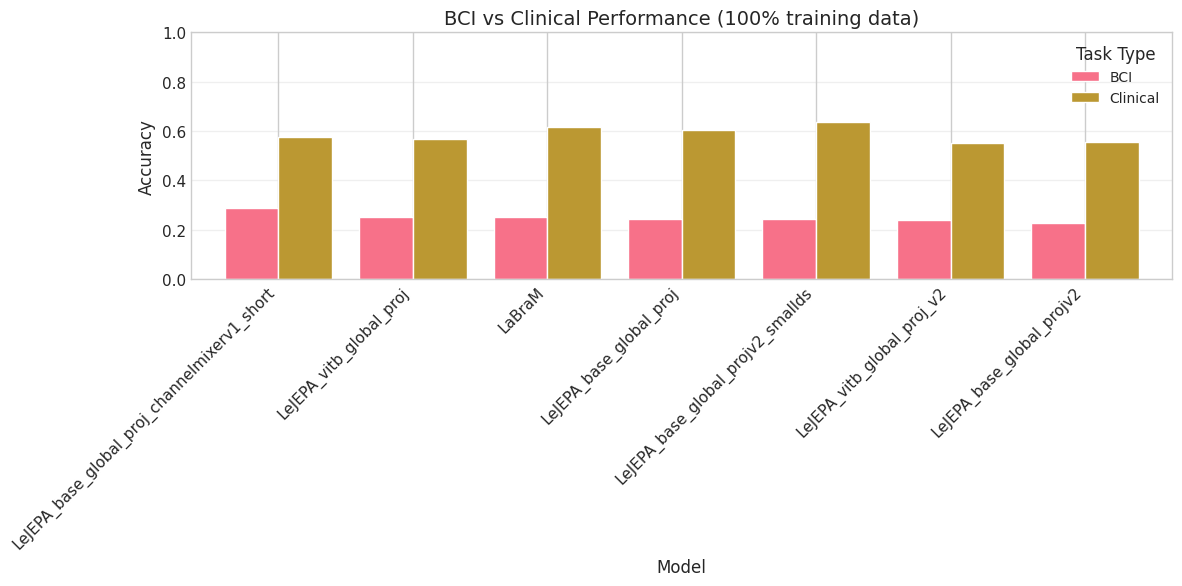

Saved to results/bci_vs_clinical.png


In [189]:
# BCI vs Clinical comparison
if len(df) > 0:
    plot_bci_vs_clinical(df)

## 6. Export Results

In [135]:
# Export full results to CSV
if len(df) > 0:
    output_path = "results/analysis_summary.csv"
    df.to_csv(output_path, index=False)
    print(f"Exported results to {output_path}")
    
    # Also export comparison table
    table = model_comparison_table(df, percentage=1.0)
    if table is not None:
        table.to_csv("results/model_comparison_table.csv")
        print("Exported comparison table to results/model_comparison_table.csv")

Exported results to results/analysis_summary.csv
Exported comparison table to results/model_comparison_table.csv


## 7. Custom Analysis

Use the cells below for your own analysis.

In [136]:
# Example: Filter and analyze specific subset
# df_lejepa = df[df["model_display"] == "LeJEPA"]
# df_bci = df[df["task_type"] == "BCI"]
# df_low_data = df[df["percentage"] <= 0.1]

In [137]:
# Example: Compare linear probe vs full fine-tuning (if both available)
# if "linear_probe" in df.columns and df["linear_probe"].nunique() > 1:
#     lp_comparison = df.groupby(["model_display", "linear_probe"])["accuracy"].mean().unstack()
#     display(lp_comparison)

## Additional Experiments: Noise Robustness

All plots above use clean-only results. This section visualizes the noise sweeps.


In [ ]:
df_for_noiseplot = df_all[(df_all["task"] == 'abnormal_clinical') & (df_all["percentage"] == 1.0)]
clean_baseline = df_for_noiseplot[df_for_noiseplot["is_clean"]].groupby("model_display")["balanced_accuracy"].mean()

In [ ]:
noise_to_plot  = df_for_noiseplot[~df_for_noiseplot["is_clean"]].sort_values("noise_snr_db", ascending=False)
noise_to_plot['noise_types_str'] = noise_to_plot['noise_types_str'].fillna(noise_to_plot['noise_types'])
noise_to_plot['noise_types_str'] = noise_to_plot['noise_types_str'].replace('gaussian+one_over_f+emg+channel_dropout', 'all')
noise_to_plot['model_display'] = noise_to_plot['model_display'].str.split('_noise').apply(lambda x: x[0])

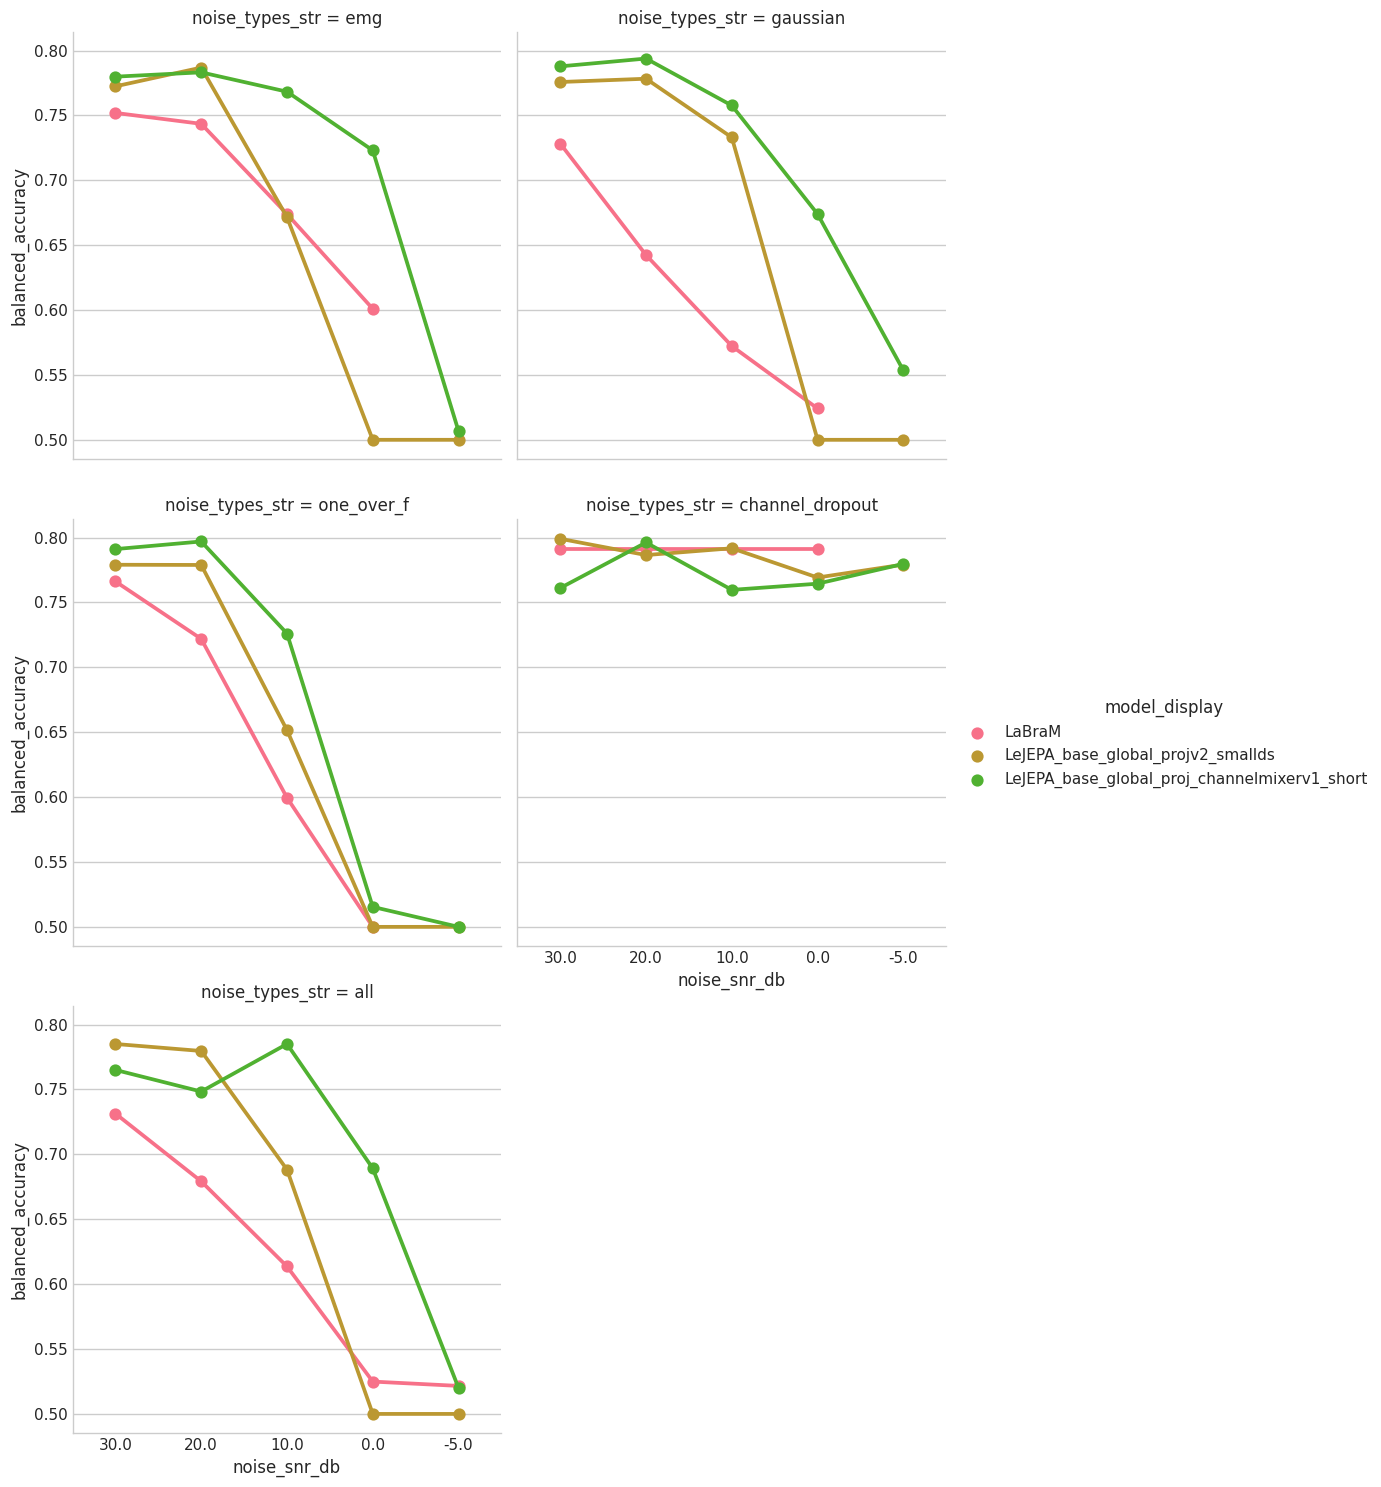

In [143]:
sns.catplot(
    data=noise_to_plot,
    x="noise_snr_db",
    y="balanced_accuracy",
    hue="model_display",
    col="noise_types_str",
    kind="point",
    col_wrap=2
    
    # height=4,
    # aspect=1.2,
    # dodge=True,
    # markers=["o", "s", "D", "^", "v", "P", "X"],
    # linestyles="solid",
    # ci=None
)
plt.gca().invert_xaxis()  # Higher noise to the right visually (optional)


/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/spanchavati/anaconda3/envs/eeg_bench/lib/python3.10/site-packa

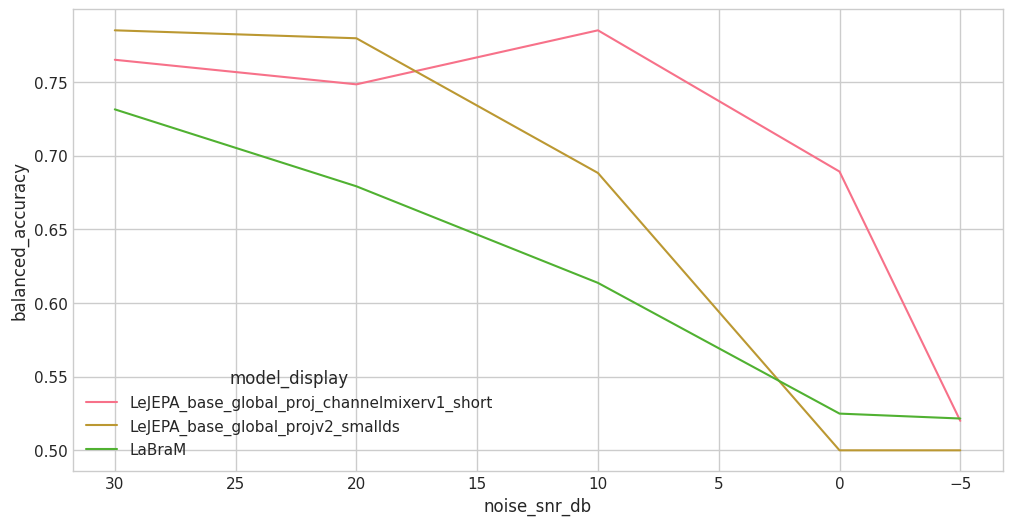

In [144]:
sns.lineplot(data=noise_to_plot[noise_to_plot['noise_types_str'] == 'all'], x='noise_snr_db', y='balanced_accuracy', hue='model_display', markers=True, dashes=False)
plt.gca().invert_xaxis()  # Higher noise to the right visually (optional)
